# Notebook 1 - Klasifikasi Gaya Belajar Mahasiswa
**Mata Kuliah:** Pembelajaran Mesin - UAS Genap T.A. 2025/2026
**Program Studi:** Informatika, Universitas Atma Jaya Yogyakarta
**Dosen:** Yohanes Sigit Purnomo, Ph.D. & Theresia Devi Indriasari, Ph.D.

---
Model klasifikasi gaya belajar (Visual, Auditory, ReadWrite, Kinesthetic) berdasarkan survei VARK.

## 1. Import Library

In [1]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
sns.set_theme(style='whitegrid', palette='Set2')

from sklearn.pipeline            import Pipeline
from sklearn.compose             import ColumnTransformer
from sklearn.preprocessing       import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.impute              import SimpleImputer

from sklearn.feature_selection   import SelectKBest, SelectPercentile, f_classif

from sklearn.model_selection     import (train_test_split, GridSearchCV,
                                         StratifiedKFold, cross_validate,
                                         cross_val_score)

from sklearn.linear_model        import LogisticRegression
from sklearn.neighbors           import KNeighborsClassifier
from sklearn.tree                import DecisionTreeClassifier
from sklearn.ensemble            import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm                 import SVC

from sklearn.metrics             import (accuracy_score, precision_score,
                                         recall_score, f1_score,
                                         classification_report,
                                         ConfusionMatrixDisplay,
                                         confusion_matrix)

import joblib
import sklearn

RANDOM_STATE = 99
print(f"scikit-learn   = {sklearn.__version__}")
print(f"joblib         = {joblib.__version__}")
print(f"pandas         = {pd.__version__}")
print(f"numpy          = {np.__version__}")

scikit-learn   = 1.9.0
joblib         = 1.5.3
pandas         = 3.0.4
numpy          = 2.2.6


## 2. Data Loading
Dataset yang digunakan adalah hasil survei preferensi belajar, kebiasaan belajar, dan faktor akademik mahasiswa yang telah **dianonimkan** (kolom identitas dihapus).


In [2]:
FILE_PATH = 'ANONIM_Survei Preferensi Belajar, Kebiasaan Belajar, dan Faktor Akademik Mahasiswa (Responses).xlsx'
df_raw = pd.read_excel(FILE_PATH)

print(f"Shape  : {df_raw.shape[0]} baris x {df_raw.shape[1]} kolom")

Shape  : 324 baris x 89 kolom


In [3]:
# ── Head ──────────────────────────────────────────────────────────────────────
df_raw.head(3)


,Timestamp,Pernyataan Persetujuan,Program studi,Semester saat ini,Jenis kelamin,Usia (tahun),Status tempat tinggal selama kuliah,Apakah Anda bekerja sambil kuliah?,Sumber pembiayaan utama kuliah saya saat ini adalah:,Rata-rata waktu belajar mandiri per hari di luar jam kuliah,...,"Saat belajar di rumah, saya mengerjakan latihan soal, tugas, atau kuis untuk memahami materi.","Saat belajar sendiri, saya mencoba langsung langkah-langkah atau prosedur yang sedang dipelajari.","Saat mempelajari materi, saya menggunakan contoh kasus nyata agar lebih mudah memahami konsep.","Saat belajar di rumah, saya melakukan simulasi, praktik, eksperimen, atau demonstrasi kecil sesuai materi yang dipelajari.","Saat merasa belum paham, saya mencoba sendiri sampai mengetahui cara kerja atau penyelesaian dari materi tersebut.","Saat merasa belum paham, saya mencoba sendiri sampai mengetahui cara kerja atau penyelesaian dari materi tersebut. 2",IPK kumulatif saat ini,IPS semester terakhir,"Dalam satu semester terakhir, apakah Anda pernah mengulang mata kuliah?","Dalam satu semester terakhir, apakah Anda pernah mendapat nilai D/E?"
0,2026-03-17 16:11:14.219,Saya BERSEDIA mengikuti survei ini secara suka...,Arsitektur,6,Perempuan,20.0,Kost/asrama,Tidak,"Orang tua / keluarga, Beasiswa sebagian",1–2 jam,...,3.0,3.0,3.0,3.0,4.0,3.0,3.20,2.80,Tidak,Tidak
1,2026-03-17 16:23:55.853,Saya BERSEDIA mengikuti survei ini secara suka...,informatika,6,Perempuan,21.0,Bersama orang tua,Tidak,"Orang tua / keluarga, Beasiswa penuh",2–3 jam,...,3.0,3.0,3.0,2.0,3.0,4.0,3.07,3.91,Tidak,Tidak
2,2026-03-17 16:31:47.507,Saya BERSEDIA mengikuti survei ini secara suka...,Informatika,6,Laki-laki,20.0,Bersama orang tua,Tidak,Orang tua / keluarga,Kurang dari 1 jam,...,4.0,4.0,3.0,4.0,4.0,4.0,3.51,3.51,Tidak,Tidak


In [4]:
# ── Info ──────────────────────────────────────────────────────────────────────
df_raw.info(verbose=True, show_counts=True)


<class 'pandas.DataFrame'>
RangeIndex: 324 entries, 0 to 323
Data columns (total 89 columns):
 #   Column                                                                                                                         Non-Null Count  Dtype         
---  ------                                                                                                                         --------------  -----         
 0   Timestamp                                                                                                                      324 non-null    datetime64[us]
 1   Pernyataan Persetujuan                                                                                                         324 non-null    str           
 2    Program studi                                                                                                                 323 non-null    object        
 3    Semester saat ini                                                                    

In [5]:
# ── Statistik deskriptif (kolom numerik) ─────────────────────────────────────
df_raw.describe().round(2)


,Timestamp,Usia (tahun),Kualitas akses internet untuk belajar,Kehadiran perkuliahan saya selama satu semester terakhir secara umum,"Saya lebih mudah memahami materi jika disajikan dalam bentuk diagram, bagan, atau infografik.",Saya lebih mudah mengingat materi ketika dosen menggunakan slide yang jelas dan visual.,"Warna, simbol, atau penanda visual membantu saya memahami konsep.",Saya lebih suka membuat peta konsep atau mind map saat belajar.,Saya lebih cepat memahami penjelasan jika disertai ilustrasi atau video.,Saya lebih mudah memahami materi dengan mendengarkan penjelasan lisan dosen.,...,"Saat menemukan materi yang sulit, saya mencari penjelasan tertulis dari buku, modul, artikel, atau internet.","Saat menghafal konsep atau istilah, saya menuliskannya berulang kali agar lebih ingat.","Saat belajar di rumah, saya mengerjakan latihan soal, tugas, atau kuis untuk memahami materi.","Saat belajar sendiri, saya mencoba langsung langkah-langkah atau prosedur yang sedang dipelajari.","Saat mempelajari materi, saya menggunakan contoh kasus nyata agar lebih mudah memahami konsep.","Saat belajar di rumah, saya melakukan simulasi, praktik, eksperimen, atau demonstrasi kecil sesuai materi yang dipelajari.","Saat merasa belum paham, saya mencoba sendiri sampai mengetahui cara kerja atau penyelesaian dari materi tersebut.","Saat merasa belum paham, saya mencoba sendiri sampai mengetahui cara kerja atau penyelesaian dari materi tersebut. 2",IPK kumulatif saat ini,IPS semester terakhir
count,324,323.00,323.00,323.00,323.00,323.00,323.00,323.00,323.00,323.00,...,323.00,323.00,323.00,323.00,323.00,323.00,323.00,323.00,323.00,323.00
mean,2026-04-21 19:47:46.415814,20.93,4.04,4.58,3.73,4.32,4.36,3.48,4.31,3.75,...,4.02,3.77,3.87,3.93,3.99,3.73,4.02,4.05,10.91,10.32
min,2026-03-17 16:11:14.219000,18.00,1.00,2.00,1.00,1.00,2.00,1.00,2.00,1.00,...,2.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,2.00,0.00
25%,2026-04-14 22:12:47.149500,20.00,4.00,4.00,3.00,4.00,4.00,3.00,4.00,3.00,...,3.00,3.00,3.00,3.00,3.00,3.00,3.50,3.50,3.36,3.50
50%,2026-04-25 00:01:07.254500,21.00,4.00,5.00,4.00,4.00,4.00,3.00,4.00,4.00,...,4.00,4.00,4.00,4.00,4.00,4.00,4.00,4.00,3.60,3.70
75%,2026-04-28 21:40:19.310250,21.00,5.00,5.00,4.00,5.00,5.00,4.00,5.00,5.00,...,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,3.80,3.90
max,2026-05-02 14:11:52.871000,26.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,...,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,390.00,380.00
std,NaN,1.21,0.84,0.68,0.93,0.78,0.71,1.12,0.80,0.99,...,0.83,1.08,0.92,0.84,0.88,1.01,0.83,0.83,49.99,45.20


## 3. Exploratory Data Analysis (EDA)
Pada bagian ini kita menggali karakteristik dataset secara menyeluruh sebelum pemodelan.


In [6]:
print(f"Jumlah data      : {df_raw.shape[0]}")
print(f"Jumlah kolom     : {df_raw.shape[1]}")
print()

dtype_summary = df_raw.dtypes.value_counts()
print("Tipe data:")
for dtype, count in dtype_summary.items():
    print(f"  {dtype}: {count} kolom")

Jumlah data      : 324
Jumlah kolom     : 89

Tipe data:
  float64: 77 kolom
  str: 9 kolom
  object: 2 kolom
  datetime64[us]: 1 kolom


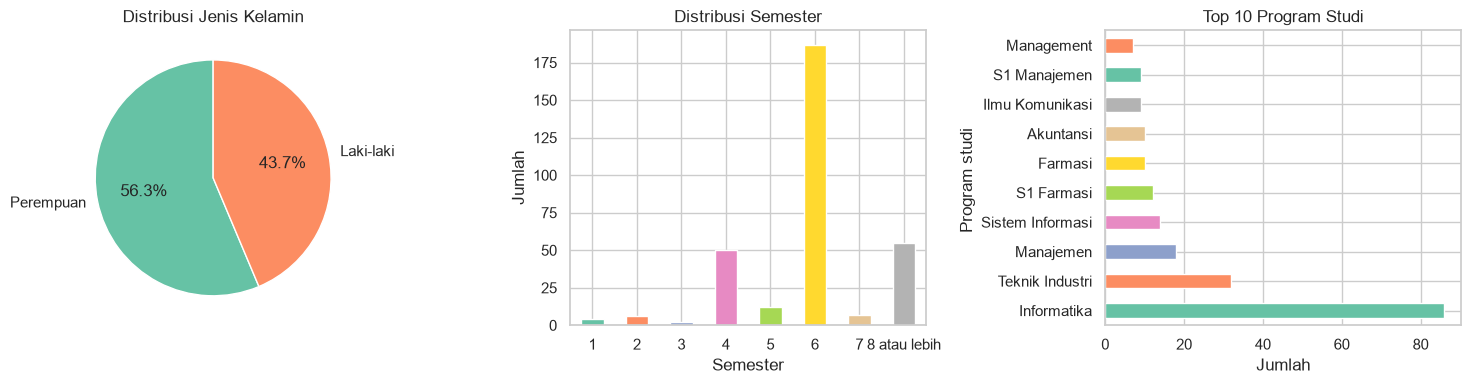

In [7]:
col_gender = ' Jenis kelamin  '
col_prodi  = ' Program studi  '
col_smt    = ' Semester saat ini  '

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

gender_counts = df_raw[col_gender].value_counts()
axes[0].pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', startangle=90)
axes[0].set_title('Distribusi Jenis Kelamin')

smt_counts = df_raw[col_smt].value_counts()
smt_order = sorted(smt_counts.index, key=lambda x: int(str(x).split()[0]))
smt_counts = smt_counts.reindex(smt_order)
smt_counts.plot(kind='bar', ax=axes[1], color=sns.color_palette('Set2'))
axes[1].set_title('Distribusi Semester')
axes[1].set_xlabel('Semester'); axes[1].set_ylabel('Jumlah')
axes[1].tick_params(axis='x', rotation=0)

prodi_counts = df_raw[col_prodi].str.strip().str.title().value_counts().head(10)
prodi_counts.plot(kind='barh', ax=axes[2], color=sns.color_palette('Set2'))
axes[2].set_title('Top 10 Program Studi')
axes[2].set_xlabel('Jumlah')

plt.tight_layout()
plt.show()

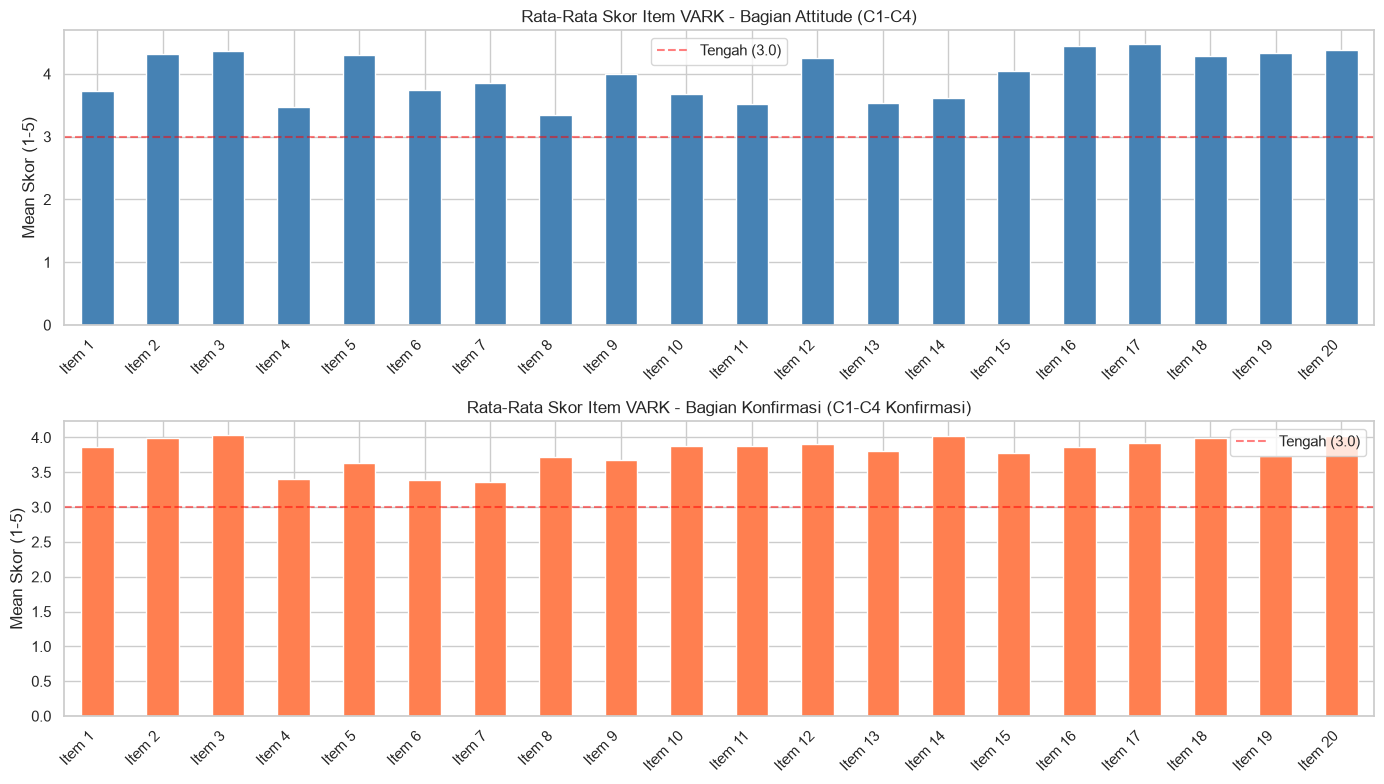

In [8]:
vark_attitude_cols  = list(df_raw.columns[13:33])
vark_confirm_cols   = list(df_raw.columns[64:84])

means_att  = df_raw[vark_attitude_cols].mean()
means_conf = df_raw[vark_confirm_cols].mean()

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
means_att.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Rata-Rata Skor Item VARK - Bagian Attitude (C1-C4)')
axes[0].set_ylabel('Mean Skor (1-5)')
axes[0].set_xticklabels([f'Item {i+1}' for i in range(20)], rotation=45, ha='right')
axes[0].axhline(y=3, color='red', linestyle='--', alpha=0.5, label='Tengah (3.0)')
axes[0].legend()

means_conf.plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Rata-Rata Skor Item VARK - Bagian Konfirmasi (C1-C4 Konfirmasi)')
axes[1].set_ylabel('Mean Skor (1-5)')
axes[1].set_xticklabels([f'Item {i+1}' for i in range(20)], rotation=45, ha='right')
axes[1].axhline(y=3, color='red', linestyle='--', alpha=0.5, label='Tengah (3.0)')
axes[1].legend()

plt.tight_layout()
plt.show()

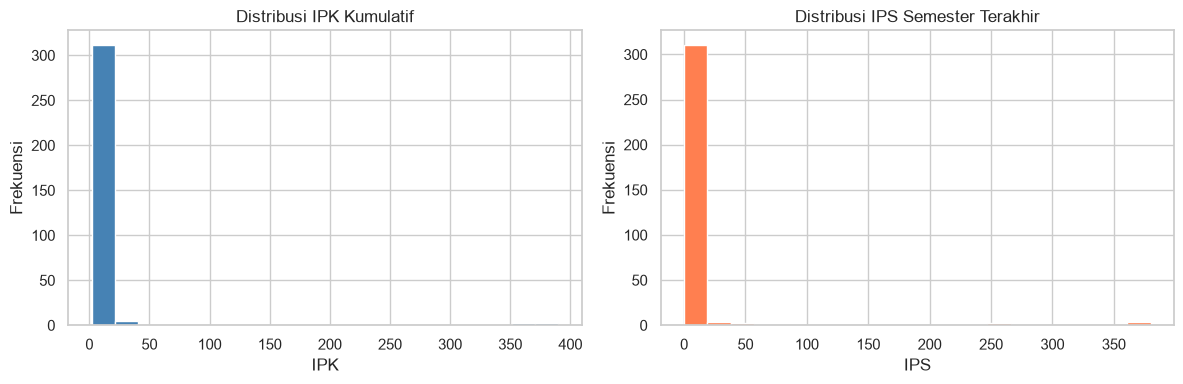

In [9]:
col_ipk = '  IPK kumulatif saat ini  '
col_ips = ' IPS semester terakhir  '

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df_raw[col_ipk].dropna(), bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('Distribusi IPK Kumulatif')
axes[0].set_xlabel('IPK'); axes[0].set_ylabel('Frekuensi')

axes[1].hist(df_raw[col_ips].dropna(), bins=20, color='coral', edgecolor='white')
axes[1].set_title('Distribusi IPS Semester Terakhir')
axes[1].set_xlabel('IPS'); axes[1].set_ylabel('Frekuensi')

plt.tight_layout()
plt.show()

## 4. Data Checking
Pemeriksaan kualitas data: missing value, NaN, empty string, duplikasi, dan outlier.


In [10]:
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_df = pd.DataFrame({'Missing': missing, 'Persen (%)': missing_pct})
missing_df = missing_df[missing_df['Missing'] > 0].sort_values('Missing', ascending=False)
print(f"Kolom dengan missing value: {len(missing_df)}")
display(missing_df.head(20))

Kolom dengan missing value: 87


,Missing,Persen (%)
Program studi,1,0.31
Semester saat ini,1,0.31
Jenis kelamin,1,0.31
Usia (tahun),1,0.31
Status tempat tinggal selama kuliah,1,0.31
Apakah Anda bekerja sambil kuliah?,1,0.31
Sumber pembiayaan utama kuliah saya saat ini adalah:,1,0.31
Rata-rata waktu belajar mandiri per hari di luar jam kuliah,1,0.31
Perangkat utama yang digunakan untuk belajar,1,0.31
Kualitas akses internet untuk belajar,1,0.31


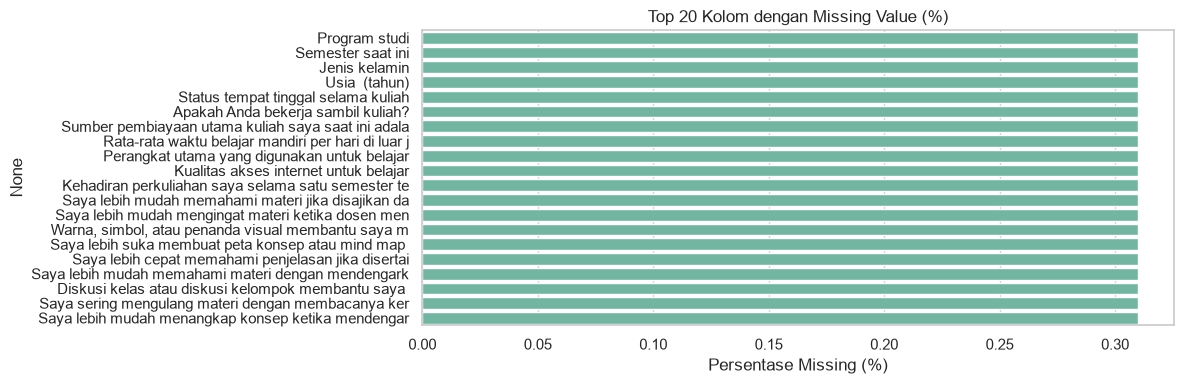

In [11]:
plt.figure(figsize=(12, 4))
missing_df_top = missing_df.head(20)
sns.barplot(x=missing_df_top['Persen (%)'], y=missing_df_top.index.str.strip().str[:50])
plt.title('Top 20 Kolom dengan Missing Value (%)')
plt.xlabel('Persentase Missing (%)')
plt.tight_layout()
plt.show()

In [12]:
obj_cols = df_raw.select_dtypes(include='object').columns
empty_str = {}
for c in obj_cols:
    n = (df_raw[c].astype(str).str.strip() == '').sum()
    if n > 0:
        empty_str[c] = n
print("Kolom dengan empty string:", empty_str if empty_str else "Tidak ada")

Kolom dengan empty string: Tidak ada


In [13]:
# ── Duplikasi ──────────────────────────────────────────────────────────────────
dup_count = df_raw.duplicated().sum()
print(f"Jumlah baris duplikat: {dup_count}")


Jumlah baris duplikat: 0


In [14]:
likert_cols = list(df_raw.columns[13:33]) + list(df_raw.columns[64:84])
outlier_summary = []
for c in likert_cols:
    vals = df_raw[c].dropna()
    Q1, Q3 = vals.quantile(0.25), vals.quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((vals < Q1 - 1.5*IQR) | (vals > Q3 + 1.5*IQR)).sum()
    if n_out > 0:
        outlier_summary.append({'Kolom': c.strip()[:60], 'Outlier': n_out})

print(f"Jumlah kolom Likert dengan outlier (IQR): {len(outlier_summary)}")
if outlier_summary:
    display(pd.DataFrame(outlier_summary).head(10))
else:
    print("Tidak ada outlier signifikan pada skala Likert 1-5.")

Jumlah kolom Likert dengan outlier (IQR): 20


,Kolom,Outlier
0,Saya lebih mudah memahami materi jika disajika...,4
1,Saya lebih mudah mengingat materi ketika dosen...,8
2,"Warna, simbol, atau penanda visual membantu sa...",3
3,Saya lebih suka membuat peta konsep atau mind ...,13
4,Saya lebih cepat memahami penjelasan jika dise...,7
5,Saya sering mengulang materi dengan membacanya...,17
6,"Saya lebih suka belajar dari buku, modul, atau...",7
7,Saya lebih mudah memahami materi dengan mencat...,9
8,Saya suka membuat rangkuman tertulis setelah p...,11
9,Saya lebih nyaman menerima instruksi dalam ben...,9


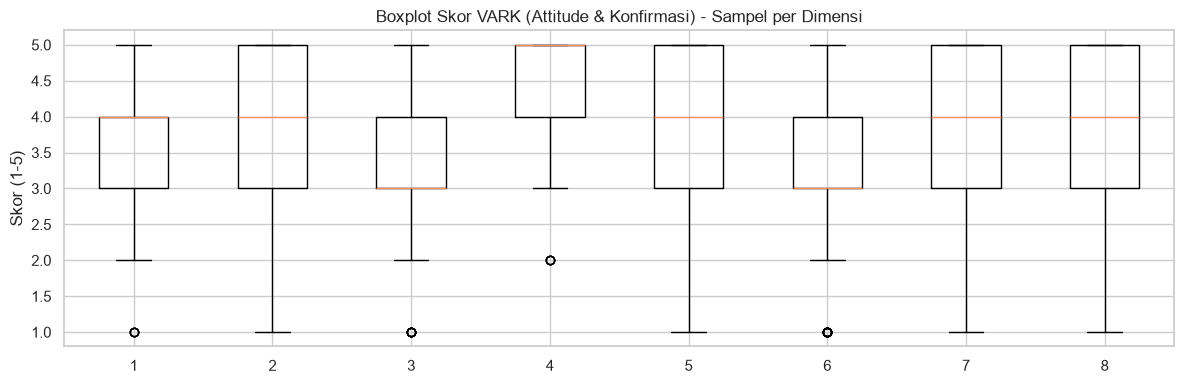

In [15]:
sample_cols = [df_raw.columns[13], df_raw.columns[18],
               df_raw.columns[23], df_raw.columns[28],
               df_raw.columns[64], df_raw.columns[69],
               df_raw.columns[74], df_raw.columns[79]]
labels = ['V-att','A-att','R-att','K-att','V-conf','A-conf','R-conf','K-conf']

fig, ax = plt.subplots(figsize=(12, 4))
ax.boxplot([df_raw[c].dropna() for c in sample_cols], label=labels)
ax.set_title('Boxplot Skor VARK (Attitude & Konfirmasi) - Sampel per Dimensi')
ax.set_ylabel('Skor (1-5)')
plt.tight_layout()
plt.show()

## 5. Data Preparation

In [16]:
df = df_raw.copy()

drop_cols = [df.columns[0], df.columns[1]]
df.drop(columns=drop_cols, inplace=True)
print(f"Setelah hapus kolom identitas: {df.shape}")

Setelah hapus kolom identitas: (324, 87)


In [17]:
dup_col_names = [c for c in df.columns if c.endswith(' 2') or c.endswith(' 2 ')]
print(f"Kolom duplikat ditemukan ({len(dup_col_names)}): {dup_col_names}")
df.drop(columns=dup_col_names, inplace=True)
print(f"Setelah hapus kolom duplikat: {df.shape}")

Kolom duplikat ditemukan (2): ['Saya jarang menunda mengerjakan tugas sampai mendekati tenggat waktu.  2', 'Saat merasa belum paham, saya mencoba sendiri sampai mengetahui cara kerja atau penyelesaian dari materi tersebut.  2']
Setelah hapus kolom duplikat: (324, 85)


In [18]:
n_before = len(df)
df.dropna(thresh=int(len(df.columns) * 0.5), inplace=True)
df.reset_index(drop=True, inplace=True)
print(f"Baris dihapus karena missing > 50%: {n_before - len(df)}")
print(f"Baris tersisa: {len(df)}")
print(f"Missing value tersisa: {df.isnull().sum().sum()}")

Baris dihapus karena missing > 50%: 1
Baris tersisa: 323
Missing value tersisa: 0


In [19]:
def reverse_code(series):
    return 6 - series

col_E5 = [c for c in df.columns if 'Hambatan teknis' in c][0]
col_F5 = [c for c in df.columns if 'terdistraksi' in c][0]

print(f"Reverse coding kolom:")
print(f"  E5: {col_E5.strip()[:70]}")
print(f"  F5: {col_F5.strip()[:70]}")

df[col_E5] = reverse_code(df[col_E5])
df[col_F5] = reverse_code(df[col_F5])

Reverse coding kolom:
  E5: Hambatan teknis seperti internet atau perangkat sering mengganggu pros
  F5: Saya mudah terdistraksi oleh penggunaan perangkat digital saat sedang 


In [20]:
col_prodi = ' Program studi  '
df[col_prodi] = df[col_prodi].str.strip().str.title()
print(f"Nilai unik program studi: {df[col_prodi].nunique()}")
print(f"Shape akhir dataset bersih: {df.shape}")

Nilai unik program studi: 90
Shape akhir dataset bersih: (323, 85)


## 6. Feature Engineering — Membuat Target `LearningStyle`
Label gaya belajar dibuat berdasarkan panduan survei:
- **Visual** = rata-rata 10 item Visual (5 attitude + 5 konfirmasi)
- **Auditory** = rata-rata 10 item Auditory
- **ReadWrite** = rata-rata 10 item ReadWrite
- **Kinesthetic** = rata-rata 10 item Kinesthetic
- Label = dimensi dengan skor rata-rata tertinggi


In [21]:
visual_att    = [c for c in df.columns if any(k in c for k in [
    'diagram, bagan, atau infografik',
    'slide yang jelas dan visual',
    'Warna, simbol, atau penanda visual',
    'peta konsep atau mind map saat belajar',
    'ilustrasi atau video'])]

auditory_att  = [c for c in df.columns if any(k in c for k in [
    'mendengarkan penjelasan lisan dosen',
    'Diskusi kelas atau diskusi kelompok',
    'membacanya keras-keras atau menjelaskannya secara verbal',
    'mendengar contoh yang dijelaskan secara lisan',
    'rekaman audio atau penjelasan verbal membantu'])]

readwrite_att = [c for c in df.columns if any(k in c for k in [
    'buku, modul, atau artikel tertulis',
    'mencatat ulang poin-poin penting',
    'rangkuman tertulis setelah perkuliahan',
    'instruksi dalam bentuk tulisan daripada penjelasan lisan',
    'istilah atau konsep ketika menuliskannya'])]

kinesthetic_att = [c for c in df.columns if any(k in c for k in [
    'langsung mempraktikkannya',
    'Contoh kasus nyata membuat saya lebih cepat',
    'simulasi, eksperimen, atau demonstrasi',
    'mencoba sendiri langkah-langkahnya',
    'praktik daripada hanya membaca teori'])]

visual_conf    = [c for c in df.columns if any(k in c for k in [
    'slide, diagram, bagan, atau infografik untuk memahami',
    'mencari video pembelajaran untuk membantu',
    'highlight, warna, simbol, atau tanda khusus',
    'mind map, peta konsep, atau skema ringkas',
    'gambar, ilustrasi, tabel, atau tampilan visual lain'])]

auditory_conf  = [c for c in df.columns if any(k in c for k in [
    'mendengarkan ulang rekaman penjelasan atau audio',
    'suara keras agar lebih mudah memahami isi',
    'menjelaskan materi dengan lisan kepada diri sendiri',
    'berdiskusi dengan teman, baik secara langsung',
    'penjelasan berbentuk suara atau video yang menjelaskan materi secara verbal'])]

readwrite_conf = [c for c in df.columns if any(k in c for k in [
    'membaca ulang catatan kuliah, modul',
    'menulis ulang poin-poin penting dari materi',
    'rangkuman tertulis dengan bahasa saya sendiri',
    'penjelasan tertulis dari buku, modul, artikel, atau internet',
    'menuliskannya berulang kali agar lebih ingat'])]

kinesthetic_conf = [c for c in df.columns if any(k in c for k in [
    'latihan soal, tugas, atau kuis untuk memahami',
    'mencoba langsung langkah-langkah atau prosedur',
    'contoh kasus nyata agar lebih mudah memahami konsep',
    'simulasi, praktik, eksperimen, atau demonstrasi kecil',
    'mencoba sendiri sampai mengetahui cara kerja'])]

visual_all      = visual_att    + visual_conf
auditory_all    = auditory_att  + auditory_conf
readwrite_all   = readwrite_att + readwrite_conf
kinesthetic_all = kinesthetic_att + kinesthetic_conf

print("Jumlah item per dimensi:")
print(f"  Visual      : {len(visual_all)} item")
print(f"  Auditory    : {len(auditory_all)} item")
print(f"  ReadWrite   : {len(readwrite_all)} item")
print(f"  Kinesthetic : {len(kinesthetic_all)} item")

Jumlah item per dimensi:
  Visual      : 11 item
  Auditory    : 10 item
  ReadWrite   : 10 item
  Kinesthetic : 10 item


In [22]:
df['score_Visual']      = df[visual_all].mean(axis=1)
df['score_Auditory']    = df[auditory_all].mean(axis=1)
df['score_ReadWrite']   = df[readwrite_all].mean(axis=1)
df['score_Kinesthetic'] = df[kinesthetic_all].mean(axis=1)

score_cols = ['score_Visual', 'score_Auditory', 'score_ReadWrite', 'score_Kinesthetic']
dim_labels = ['Visual', 'Auditory', 'ReadWrite', 'Kinesthetic']

df['LearningStyle'] = df[score_cols].idxmax(axis=1).map({
    'score_Visual'     : 'Visual',
    'score_Auditory'   : 'Auditory',
    'score_ReadWrite'  : 'ReadWrite',
    'score_Kinesthetic': 'Kinesthetic'
})

print("Distribusi LearningStyle:")
print(df['LearningStyle'].value_counts())
print(f"\nTotal data: {len(df)}")

Distribusi LearningStyle:
LearningStyle
Kinesthetic    159
Visual          74
ReadWrite       54
Auditory        36
Name: count, dtype: int64

Total data: 323


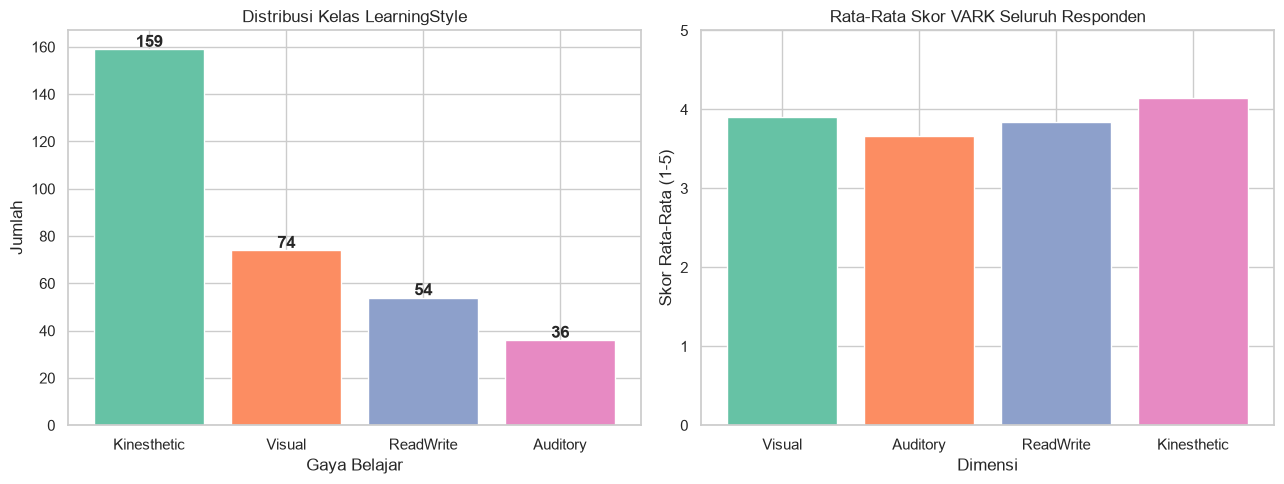

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ls_counts = df['LearningStyle'].value_counts()
colors = sns.color_palette('Set2', 4)
axes[0].bar(ls_counts.index, ls_counts.values, color=colors)
for i, v in enumerate(ls_counts.values):
    axes[0].text(i, v + 1, str(v), ha='center', fontweight='bold')
axes[0].set_title('Distribusi Kelas LearningStyle')
axes[0].set_xlabel('Gaya Belajar'); axes[0].set_ylabel('Jumlah')

score_means = df[score_cols].mean()
score_means.index = dim_labels
axes[1].bar(score_means.index, score_means.values, color=colors)
axes[1].set_title('Rata-Rata Skor VARK Seluruh Responden')
axes[1].set_xlabel('Dimensi'); axes[1].set_ylabel('Skor Rata-Rata (1-5)')
axes[1].set_ylim(0, 5)

plt.tight_layout()
plt.show()

## 7. Menentukan Fitur dan Target
Target: `LearningStyle`. Fitur kategorikal dan numerikal dipilih, kecuali kolom VARK/score (data leakage) dan kolom IPK/IPS (target notebook regresi).

In [24]:
VARK_COLS   = visual_all + auditory_all + readwrite_all + kinesthetic_all
SCORE_COLS  = score_cols
LEAK_COLS   = VARK_COLS + SCORE_COLS
DROP_COLS   = [
    '  IPK kumulatif saat ini  ',
    ' IPS semester terakhir  ',
    ' Program studi  ',
    ' Sumber pembiayaan utama kuliah saya saat ini adalah:  ',
]

CAT_FEATURES = [
    ' Jenis kelamin  ',
    ' Status tempat tinggal selama kuliah  ',
    ' Apakah Anda bekerja sambil kuliah?  ',
    ' Rata-rata waktu belajar mandiri per hari di luar jam kuliah  ',
    ' Perangkat utama yang digunakan untuk belajar  ',
    'Dalam satu semester terakhir, apakah Anda pernah mengulang mata kuliah?  ',
    'Dalam satu semester terakhir, apakah Anda pernah mendapat nilai D/E? ',
]

NUM_FEATURES_BASE = [
    ' Usia  (tahun)',
    ' Kualitas akses internet untuk belajar  ',
    ' Kehadiran perkuliahan saya selama satu semester terakhir secara umum  ',
    ' Semester saat ini  ',
]

D_COLS  = [c for c in df.columns if c.strip().startswith('Saya memiliki jadwal') or
           c.strip().startswith('Saya membagi waktu') or
           c.strip().startswith('Saya mampu menentukan') or
           c.strip().startswith('Saya jarang menunda') or
           c.strip().startswith('Saya konsisten') or
           c.strip().startswith('Saya meninjau kembali') or
           c.strip().startswith('Saya mencari sumber tambahan') or
           c.strip().startswith('Saya membandingkan berbagai sumber') or
           c.strip().startswith('Saya membuat ringkasan, poin penting') or
           c.strip().startswith('Saya mengecek sendiri') or
           c.strip().startswith('Saya memiliki target akademik') or
           c.strip().startswith('Saya tetap berusaha') or
           c.strip().startswith('Saya terdorong untuk belajar') or
           c.strip().startswith('Saya merasa bertanggung jawab') or
           c.strip().startswith('Saya berusaha memperbaiki strategi') or
           c.strip().startswith('Saya aktif bertanya') or
           c.strip().startswith('Saya mengerjakan tugas kuliah') or
           c.strip().startswith('Saya mengikuti perkuliahan dengan fokus') or
           c.strip().startswith('Saya berusaha hadir tepat waktu') or
           c.strip().startswith('Saya memanfaatkan umpan balik')]

E_COLS = [c for c in df.columns if any(k in c for k in [
    'tempat belajar yang cukup nyaman',
    'lingkungan tempat saya belajar mendukung',
    'akses perangkat yang memadai',
    'dukungan sosial yang cukup',
    'Hambatan teknis seperti internet'])]

F_COLS = [c for c in df.columns if any(k in c for k in [
    'platform digital untuk memahami',
    'Video pembelajaran atau tutorial online',
    'aplikasi atau tools digital untuk mencatat',
    'belajar secara efektif melalui media pembelajaran online',
    'terdistraksi oleh penggunaan perangkat digital'])]

NUM_FEATURES = NUM_FEATURES_BASE + D_COLS + E_COLS + F_COLS

print(f"Fitur kategorikal : {len(CAT_FEATURES)} kolom")
print(f"Fitur numerikal   : {len(NUM_FEATURES)} kolom")
print(f"  - Base numerik  : {len(NUM_FEATURES_BASE)}")
print(f"  - Kolom D       : {len(D_COLS)}")
print(f"  - Kolom E       : {len(E_COLS)}")
print(f"  - Kolom F       : {len(F_COLS)}")
print(f"\nTotal fitur       : {len(CAT_FEATURES) + len(NUM_FEATURES)}")

Fitur kategorikal : 7 kolom
Fitur numerikal   : 34 kolom
  - Base numerik  : 4
  - Kolom D       : 20
  - Kolom E       : 5
  - Kolom F       : 5

Total fitur       : 41


In [25]:
ALL_FEATURES = CAT_FEATURES + NUM_FEATURES
X = df[ALL_FEATURES].copy()
y = df['LearningStyle'].copy()

X[' Semester saat ini  '] = pd.to_numeric(X[' Semester saat ini  '], errors='coerce')

print(f"Shape X: {X.shape}")
print(f"Shape y: {y.shape}")
print(f"\nDistribusi target:")
print(y.value_counts())

Shape X: (323, 41)
Shape y: (323,)

Distribusi target:
LearningStyle
Kinesthetic    159
Visual          74
ReadWrite       54
Auditory        36
Name: count, dtype: int64


## 8. Train Test Split (80:20, stratified)

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"X_train: {X_train.shape}  |  X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}  |  y_test: {y_test.shape}")
print()
print("Distribusi kelas di training set:")
print(y_train.value_counts())
print()
print("Distribusi kelas di test set:")
print(y_test.value_counts())

X_train: (258, 41)  |  X_test: (65, 41)
y_train: (258,)  |  y_test: (65,)

Distribusi kelas di training set:
LearningStyle
Kinesthetic    127
Visual          59
ReadWrite       43
Auditory        29
Name: count, dtype: int64

Distribusi kelas di test set:
LearningStyle
Kinesthetic    32
Visual         15
ReadWrite      11
Auditory        7
Name: count, dtype: int64


## 9. Preprocessing Pipeline

In [27]:
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, NUM_FEATURES),
    ('cat', cat_transformer, CAT_FEATURES)
], remainder='drop')

## 10. Feature Selection

In [28]:
preprocessor_explore = ColumnTransformer(transformers=[
    ('num', num_transformer, NUM_FEATURES),
    ('cat', cat_transformer, CAT_FEATURES)
], remainder='drop')

X_train_transformed = preprocessor_explore.fit_transform(X_train, y_train)
n_features_after_prep = X_train_transformed.shape[1]
print(f"Jumlah fitur setelah preprocessing: {n_features_after_prep}")

Jumlah fitur setelah preprocessing: 63


## 11. Model Klasifikasi
Membandingkan 4 algoritma klasifikasi, masing-masing dalam Pipeline lengkap:
`Preprocessing → Feature Selection → Classifier`


In [29]:
pipe_lr = Pipeline([
    ('prep', preprocessor),
    ('selector', SelectKBest(score_func=f_classif)),
    ('clf', LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
])

pipe_knn = Pipeline([
    ('prep', preprocessor),
    ('selector', SelectKBest(score_func=f_classif)),
    ('clf', KNeighborsClassifier())
])

pipe_dt = Pipeline([
    ('prep', preprocessor),
    ('selector', SelectPercentile(score_func=f_classif)),
    ('clf', DecisionTreeClassifier(random_state=RANDOM_STATE))
])

pipe_rf = Pipeline([
    ('prep', preprocessor),
    ('selector', SelectPercentile(score_func=f_classif)),
    ('clf', RandomForestClassifier(random_state=RANDOM_STATE))
])

pipe_svc = Pipeline([
    ('prep', preprocessor),
    ('selector', SelectPercentile(score_func=f_classif)),
    ('clf', SVC(probability=True, random_state=RANDOM_STATE))
])

## 12. Hyperparameter Tuning (GridSearchCV)

In [30]:
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

param_grid_lr = {
    'selector__k'          : [5, 10, 15, 20, 25, 30],
    'clf__C'               : [0.01, 0.1, 1, 10, 100],
    'clf__solver'          : ['lbfgs', 'saga'],
}

gs_lr = GridSearchCV(pipe_lr, param_grid_lr, cv=cv_strategy,
                     scoring='f1_macro', n_jobs=1, verbose=0)
gs_lr.fit(X_train, y_train)
print(f"Logistic Regression — Best Params : {gs_lr.best_params_}")
print(f"Logistic Regression — Best CV F1  : {gs_lr.best_score_:.4f}")

Logistic Regression — Best Params : {'clf__C': 1, 'clf__solver': 'lbfgs', 'selector__k': 30}
Logistic Regression — Best CV F1  : 0.3775


In [31]:
param_grid_knn = {
    'selector__k'          : [5, 10, 15, 20, 25],
    'clf__n_neighbors'     : [3, 5, 7, 9, 11, 13],
    'clf__metric'          : ['euclidean', 'manhattan'],
    'clf__weights'         : ['uniform', 'distance'],
}

gs_knn = GridSearchCV(pipe_knn, param_grid_knn, cv=cv_strategy,
                      scoring='f1_macro', n_jobs=1, verbose=0)
gs_knn.fit(X_train, y_train)
print(f"KNN — Best Params : {gs_knn.best_params_}")
print(f"KNN — Best CV F1  : {gs_knn.best_score_:.4f}")

KNN — Best Params : {'clf__metric': 'euclidean', 'clf__n_neighbors': 9, 'clf__weights': 'uniform', 'selector__k': 20}
KNN — Best CV F1  : 0.3394


In [32]:
param_grid_dt = {
    'selector__percentile' : [25, 50, 75, 100],
    'clf__max_depth'       : [None, 3, 5, 7, 10, 15],
    'clf__min_samples_split': [2, 5, 10],
    'clf__min_samples_leaf' : [1, 2, 4],
    'clf__criterion'       : ['gini', 'entropy'],
}

gs_dt = GridSearchCV(pipe_dt, param_grid_dt, cv=cv_strategy,
                     scoring='f1_macro', n_jobs=1, verbose=0)
gs_dt.fit(X_train, y_train)
print(f"Decision Tree — Best Params : {gs_dt.best_params_}")
print(f"Decision Tree — Best CV F1  : {gs_dt.best_score_:.4f}")

Decision Tree — Best Params : {'clf__criterion': 'gini', 'clf__max_depth': 10, 'clf__min_samples_leaf': 2, 'clf__min_samples_split': 10, 'selector__percentile': 25}
Decision Tree — Best CV F1  : 0.3696


In [33]:
param_grid_rf = {
    'selector__percentile' : [50, 75, 100],
    'clf__n_estimators'    : [100, 200, 300, 400],
    'clf__max_depth'       : [None, 5, 10, 15],
    'clf__min_samples_split': [2, 5],
    'clf__min_samples_leaf' : [1, 2],
    'clf__max_features'    : ['sqrt', 'log2'],
}

gs_rf = GridSearchCV(pipe_rf, param_grid_rf, cv=cv_strategy,
                     scoring='f1_macro', n_jobs=1, verbose=0)
gs_rf.fit(X_train, y_train)
print(f"Random Forest — Best Params : {gs_rf.best_params_}")
print(f"Random Forest — Best CV F1  : {gs_rf.best_score_:.4f}")

Random Forest — Best Params : {'clf__max_depth': None, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 2, 'clf__n_estimators': 200, 'selector__percentile': 50}
Random Forest — Best CV F1  : 0.2896


In [34]:
param_grid_svc = {
    'selector__percentile' : [50, 75, 100],
    'clf__C'               : [0.1, 1, 10, 100],
    'clf__gamma'           : ['scale', 'auto'],
    'clf__kernel'          : ['rbf', 'linear'],
}

gs_svc = GridSearchCV(pipe_svc, param_grid_svc, cv=cv_strategy,
                      scoring='f1_macro', n_jobs=1, verbose=0)
gs_svc.fit(X_train, y_train)
print(f"SVC — Best Params : {gs_svc.best_params_}")
print(f"SVC — Best CV F1  : {gs_svc.best_score_:.4f}")

SVC — Best Params : {'clf__C': 1, 'clf__gamma': 'scale', 'clf__kernel': 'linear', 'selector__percentile': 100}
SVC — Best CV F1  : 0.3332


In [35]:
gs_results = {
    'Logistic Regression': gs_lr.best_score_,
    'KNN'               : gs_knn.best_score_,
    'Decision Tree'     : gs_dt.best_score_,
    'Random Forest'     : gs_rf.best_score_,
    'SVC'               : gs_svc.best_score_,
}
print("Ringkasan Best CV F1 Macro:")
for model, score in sorted(gs_results.items(), key=lambda x: -x[1]):
    print(f"  {model:<22}: {score:.4f}")

Ringkasan Best CV F1 Macro:
  Logistic Regression   : 0.3775
  Decision Tree         : 0.3696
  KNN                   : 0.3394
  SVC                   : 0.3332
  Random Forest         : 0.2896


## 13. Cross Validation (StratifiedKFold)

In [36]:
best_models = {
    'Logistic Regression': gs_lr.best_estimator_,
    'KNN'               : gs_knn.best_estimator_,
    'Decision Tree'     : gs_dt.best_estimator_,
    'Random Forest'     : gs_rf.best_estimator_,
    'SVC'               : gs_svc.best_estimator_,
}

cv_table = []
for name, model in best_models.items():
    cv_scores = cross_val_score(model, X_train, y_train,
                                 cv=cv_strategy, scoring='f1_macro', n_jobs=1)
    cv_table.append({
        'Model'   : name,
        'CV Mean F1' : cv_scores.mean(),
        'CV Std F1'  : cv_scores.std(),
        'Fold Scores': [round(s, 4) for s in cv_scores]
    })

cv_df = pd.DataFrame(cv_table).sort_values('CV Mean F1', ascending=False)
cv_df['CV Mean F1'] = cv_df['CV Mean F1'].round(4)
cv_df['CV Std F1']  = cv_df['CV Std F1'].round(4)
display(cv_df[['Model', 'CV Mean F1', 'CV Std F1', 'Fold Scores']])

,Model,CV Mean F1,CV Std F1,Fold Scores
0,Logistic Regression,0.3775,0.0452,"[0.3, 0.3913, 0.4242, 0.3568, 0.415]"
2,Decision Tree,0.3696,0.0495,"[0.3647, 0.3413, 0.4166, 0.4302, 0.2952]"
1,KNN,0.3394,0.0634,"[0.316, 0.2441, 0.3851, 0.4294, 0.3221]"
4,SVC,0.3332,0.0450,"[0.357, 0.3367, 0.371, 0.3551, 0.2459]"
3,Random Forest,0.2896,0.0372,"[0.3219, 0.2865, 0.255, 0.3406, 0.2441]"


## 14. Evaluasi Model pada Test Set

In [37]:
eval_results = []
for name, model in best_models.items():
    y_pred = model.predict(X_test)
    eval_results.append({
        'Model'    : name,
        'Accuracy' : accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, average='macro', zero_division=0),
        'Recall'   : recall_score(y_test, y_pred, average='macro', zero_division=0),
        'F1 Macro' : f1_score(y_test, y_pred, average='macro', zero_division=0),
    })

eval_df = pd.DataFrame(eval_results).sort_values('F1 Macro', ascending=False).reset_index(drop=True)
eval_df[['Accuracy','Precision','Recall','F1 Macro']] = \
    eval_df[['Accuracy','Precision','Recall','F1 Macro']].round(4)
display(eval_df)

,Model,Accuracy,Precision,Recall,F1 Macro
0,Decision Tree,0.3846,0.2517,0.2680,0.2588
1,SVC,0.3846,0.2343,0.2470,0.2350
2,Random Forest,0.4462,0.2801,0.2503,0.2203
3,KNN,0.4000,0.1676,0.2208,0.1902
4,Logistic Regression,0.3385,0.1406,0.1807,0.1580


In [38]:
# ── Classification Report ─────────────────────────────────────────────────────
for name, model in best_models.items():
    y_pred = model.predict(X_test)
    print(f"{'='*60}")
    print(f"  {name}")
    print(f"{'='*60}")
    print(classification_report(y_test, y_pred, zero_division=0))


  Logistic Regression
              precision    recall  f1-score   support

    Auditory       0.00      0.00      0.00         7
 Kinesthetic       0.50      0.66      0.57        32
   ReadWrite       0.00      0.00      0.00        11
      Visual       0.06      0.07      0.06        15

    accuracy                           0.34        65
   macro avg       0.14      0.18      0.16        65
weighted avg       0.26      0.34      0.29        65

  KNN
              precision    recall  f1-score   support

    Auditory       0.00      0.00      0.00         7
 Kinesthetic       0.55      0.75      0.63        32
   ReadWrite       0.00      0.00      0.00        11
      Visual       0.12      0.13      0.13        15

    accuracy                           0.40        65
   macro avg       0.17      0.22      0.19        65
weighted avg       0.30      0.40      0.34        65

  Decision Tree
              precision    recall  f1-score   support

    Auditory       0.17      0.

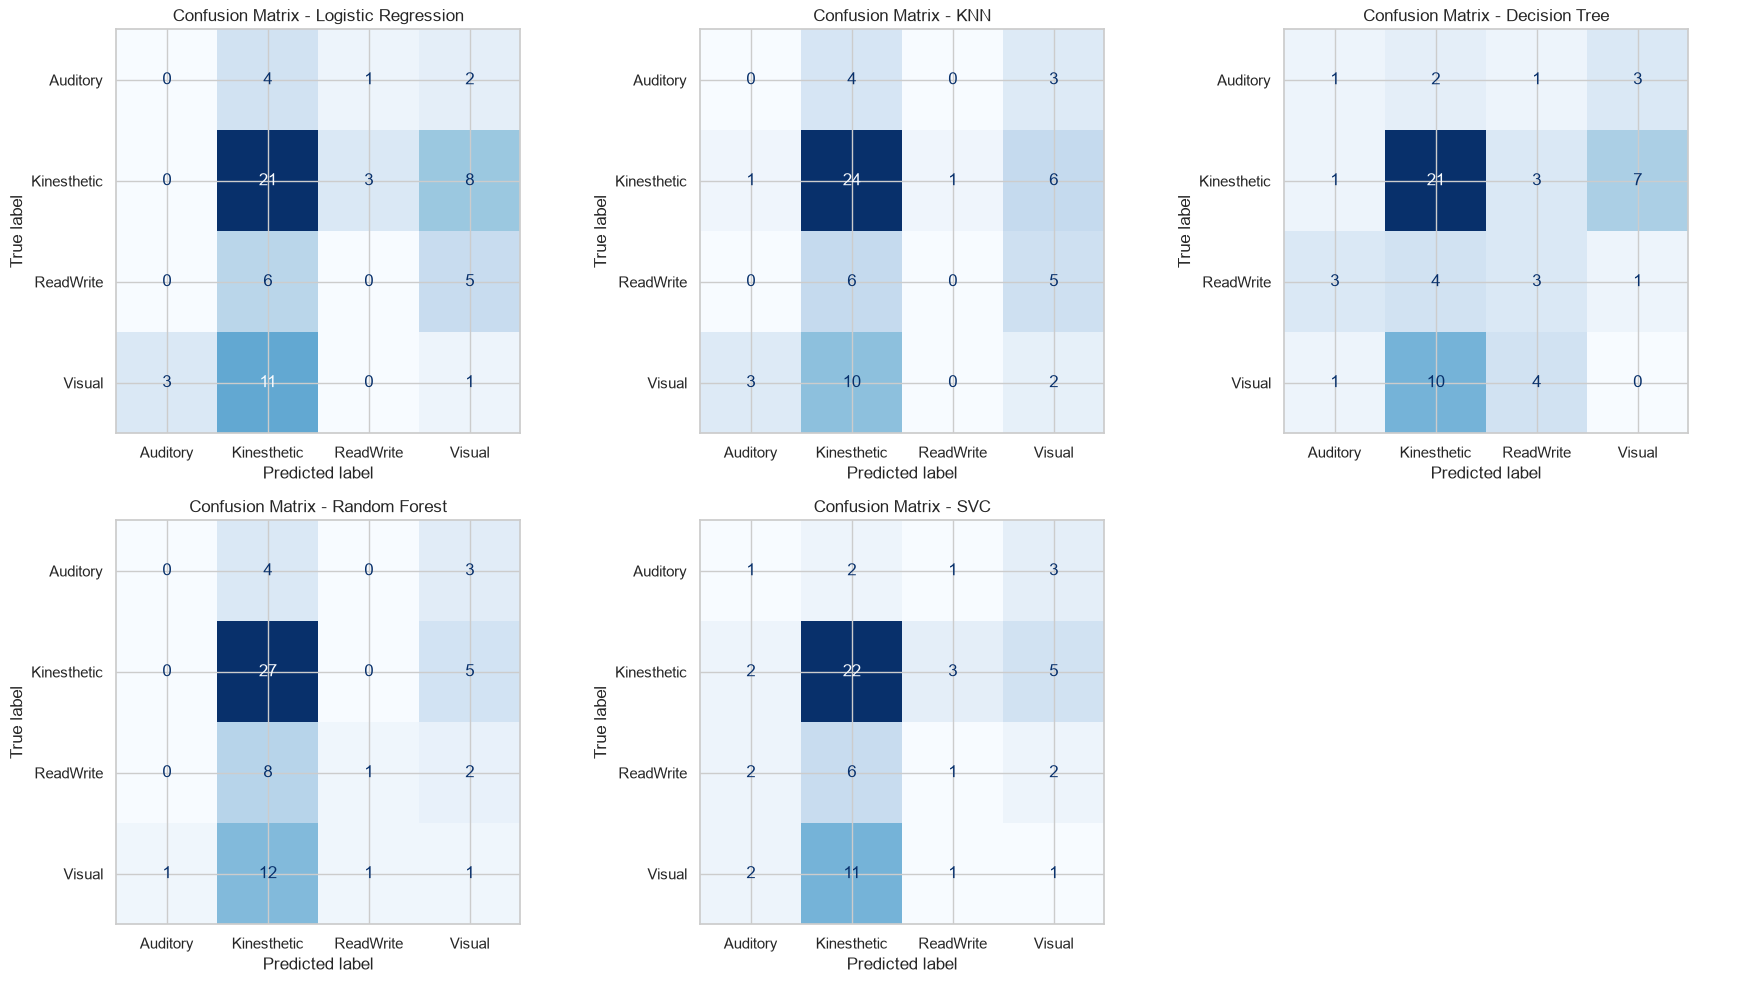

In [39]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()
class_labels = sorted(y.unique())

for idx, (name, model) in enumerate(best_models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred, labels=class_labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
    disp.plot(ax=axes[idx], colorbar=False, cmap='Blues')
    axes[idx].set_title(f'Confusion Matrix - {name}')

for j in range(len(best_models), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

## 15. Perbandingan Model

,Model,Accuracy,Precision,Recall,F1 Macro
0,Decision Tree,0.3846,0.2517,0.2680,0.2588
1,SVC,0.3846,0.2343,0.2470,0.2350
2,Random Forest,0.4462,0.2801,0.2503,0.2203
3,KNN,0.4000,0.1676,0.2208,0.1902
4,Logistic Regression,0.3385,0.1406,0.1807,0.1580


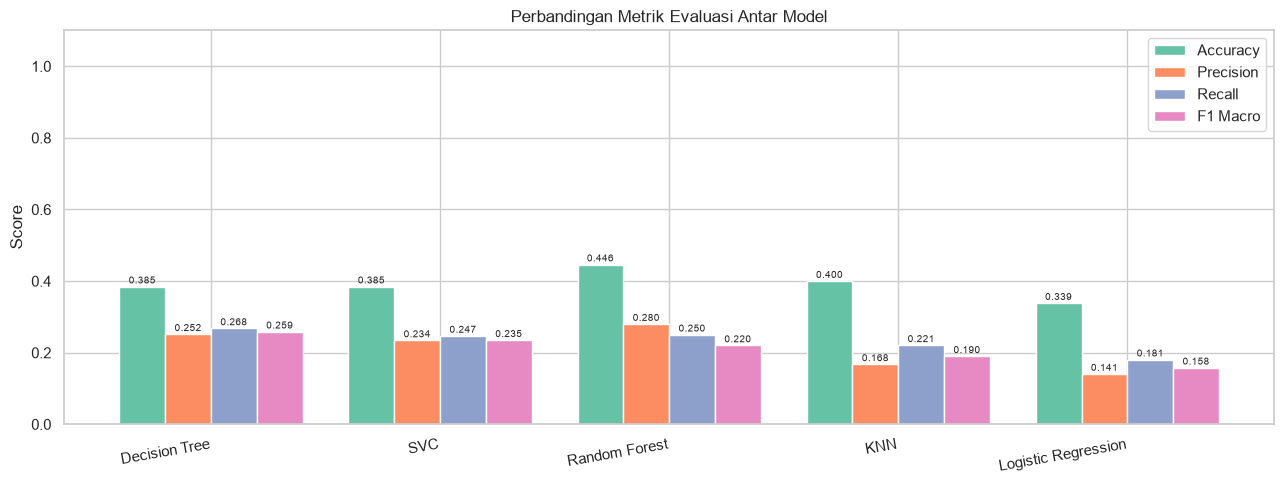

In [40]:
display(eval_df)

metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Macro']
x = np.arange(len(eval_df))
width = 0.2

fig, ax = plt.subplots(figsize=(13, 5))
for i, metric in enumerate(metrics):
    bars = ax.bar(x + i*width, eval_df[metric], width, label=metric)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., h + 0.003,
                f'{h:.3f}', ha='center', va='bottom', fontsize=7)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(eval_df['Model'], rotation=10, ha='right')
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Perbandingan Metrik Evaluasi Antar Model')
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

## 16. Analisis Feature Importance

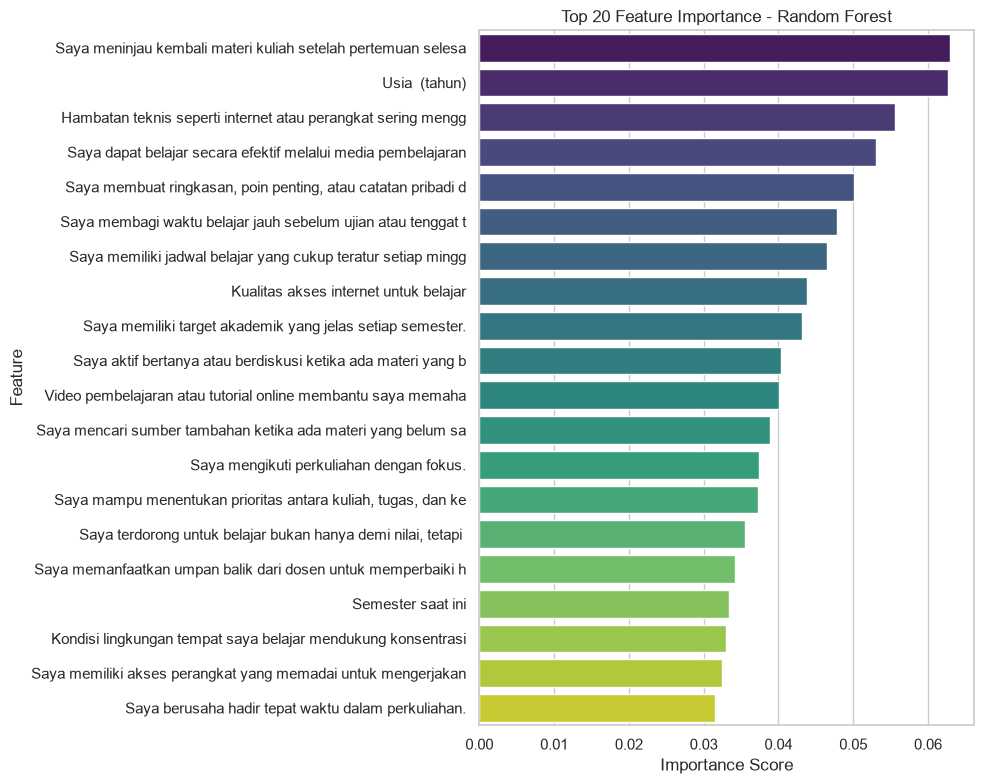

In [41]:
rf_best = gs_rf.best_estimator_

num_feature_names = NUM_FEATURES

ohe = rf_best.named_steps['prep'].named_transformers_['cat'].named_steps['encoder']
cat_feature_names = list(ohe.get_feature_names_out(CAT_FEATURES))

all_feature_names = num_feature_names + cat_feature_names

selector = rf_best.named_steps['selector']
selected_mask = selector.get_support()

selected_feature_names = [all_feature_names[i]
                           for i, sel in enumerate(selected_mask) if sel]

importances = rf_best.named_steps['clf'].feature_importances_

fi_df = pd.DataFrame({
    'Feature'   : [f.strip()[:60] for f in selected_feature_names],
    'Importance': importances
}).sort_values('Importance', ascending=False).head(20)

plt.figure(figsize=(10, 8))
sns.barplot(data=fi_df, x='Importance', y='Feature', palette='viridis')
plt.title('Top 20 Feature Importance - Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

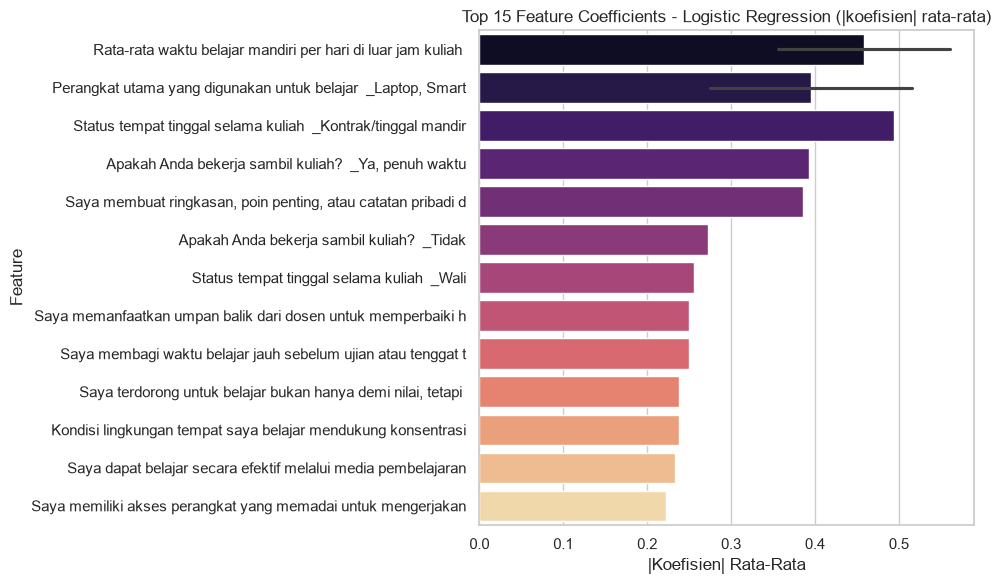

In [42]:
lr_best = gs_lr.best_estimator_
ohe_lr  = lr_best.named_steps['prep'].named_transformers_['cat'].named_steps['encoder']
cat_fn_lr = list(ohe_lr.get_feature_names_out(CAT_FEATURES))
all_fn_lr = NUM_FEATURES + cat_fn_lr

sel_lr   = lr_best.named_steps['selector']
sel_mask_lr = sel_lr.get_support()
sel_fn_lr = [all_fn_lr[i] for i, s in enumerate(sel_mask_lr) if s]

coef = np.abs(lr_best.named_steps['clf'].coef_).mean(axis=0)
lr_fi = pd.DataFrame({'Feature': [f.strip()[:60] for f in sel_fn_lr],
                       'Abs Coef': coef}).sort_values('Abs Coef', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=lr_fi, x='Abs Coef', y='Feature', palette='magma')
plt.title('Top 15 Feature Coefficients - Logistic Regression (|koefisien| rata-rata)')
plt.xlabel('|Koefisien| Rata-Rata')
plt.tight_layout()
plt.show()

## 17. Pemilihan Model Terbaik

In [43]:
display(eval_df)

best_model_name = eval_df.iloc[0]['Model']
best_f1 = eval_df.iloc[0]['F1 Macro']
print(f"Model terbaik: {best_model_name}")
print(f"F1 Macro (Test Set): {best_f1:.4f}")

,Model,Accuracy,Precision,Recall,F1 Macro
0,Decision Tree,0.3846,0.2517,0.2680,0.2588
1,SVC,0.3846,0.2343,0.2470,0.2350
2,Random Forest,0.4462,0.2801,0.2503,0.2203
3,KNN,0.4000,0.1676,0.2208,0.1902
4,Logistic Regression,0.3385,0.1406,0.1807,0.1580


Model terbaik: Decision Tree
F1 Macro (Test Set): 0.2588


## 18. Export Model

In [44]:
best_estimator_map = {
    'Logistic Regression': gs_lr.best_estimator_,
    'KNN'               : gs_knn.best_estimator_,
    'Decision Tree'     : gs_dt.best_estimator_,
    'Random Forest'     : gs_rf.best_estimator_,
    'SVC'               : gs_svc.best_estimator_,
}

best_pipeline = best_estimator_map[best_model_name]

output_path = 'BestModel_Klasifikasi_Alg_William_Luvianus_Selly_Monica.pkl'
joblib.dump(best_pipeline, output_path)
print(f"Model terbaik ({best_model_name}) disimpan ke: {output_path}")
print(f"Disimpan dengan scikit-learn versi: {sklearn.__version__}")

loaded_model = joblib.load(output_path)
sample_pred = loaded_model.predict(X_test.iloc[:5])
print(f"\nVerifikasi prediksi 5 sampel test:")
print(f"  Prediksi : {sample_pred.tolist()}")
print(f"  Aktual   : {y_test.iloc[:5].tolist()}")

Model terbaik (Decision Tree) disimpan ke: BestModel_Klasifikasi_Alg_William_Luvianus_Selly_Monica.pkl
Disimpan dengan scikit-learn versi: 1.9.0

Verifikasi prediksi 5 sampel test:
  Prediksi : ['Kinesthetic', 'Kinesthetic', 'Kinesthetic', 'ReadWrite', 'Kinesthetic']
  Aktual   : ['Kinesthetic', 'Visual', 'Visual', 'Auditory', 'Kinesthetic']


---
## Kesimpulan

Model terbaik diekspor ke `BestModel_Klasifikasi_Alg_William_Luvianus_Selly_Monica.pkl` untuk digunakan di aplikasi Streamlit.